In [248]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


1. Wczytanie danych
2. Podział danych na cechy i etykiety
3. Trenowanie i przewidywanie modelu XGBoost
Work time:  6.447075843811035 s
Confusion Matrix:
[[82615   172]
 [    5 57752]]


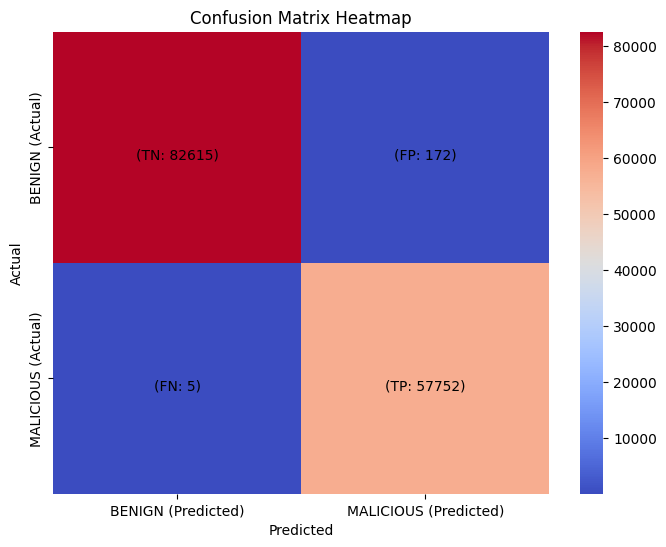

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     82787
   MALICIOUS       1.00      1.00      1.00     57757

    accuracy                           1.00    140544
   macro avg       1.00      1.00      1.00    140544
weighted avg       1.00      1.00      1.00    140544



In [249]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

import warnings
warnings.filterwarnings("ignore")

print("1. Wczytanie danych")
# day = 'Monday'
# day = 'Tuesday' 100
# day = 'Wednesday' 3
# day = 'Thursday' 500, 3500
day = 'Friday'
processed_filepath = './datasets/processed/'
data = pd.read_csv(processed_filepath + f'{day}.csv')
df = data.copy()

print("2. Podział danych na cechy i etykiety")
X = df.iloc[:, :-1].values  # Wszystkie kolumny oprócz ostatniej (cechy)
y = df.iloc[:, -1].values   # Ostatnia kolumna (etykiety)

# Podział na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("3. Trenowanie i przewidywanie modelu XGBoost")
start_time = time.time() 
xgb_model = XGBClassifier(
    n_estimators=250,  # Liczba drzew
    learning_rate=0.1,  # Współczynnik uczenia
    max_depth=6,  # Maksymalna głębokość drzewa
    scale_pos_weight=3000,  # Waga klasy mniejszościowej
    random_state=42,
    use_label_encoder=False,  # Wyłączenie ostrzeżeń o label encoderze
    eval_metric='logloss'  # Metryka ewaluacji
)

eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

y_pred = xgb_model.predict(X_test)

end_time = time.time() 
print("Work time: ", end_time - start_time, "s")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Wizualizacja macierzy konfuzji
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='coolwarm', 
                 xticklabels=['BENIGN (Predicted)', 'MALICIOUS (Predicted)'], 
                 yticklabels=['BENIGN (Actual)', 'MALICIOUS (Actual)'])

labels = [[f'TN: {cm[0][0]}', f'FP: {cm[0][1]}'], 
          [f'FN: {cm[1][0]}', f'TP: {cm[1][1]}']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, f'\n({labels[i][j]})', 
                color='Black', ha='center', va='center', fontsize=10)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'MALICIOUS']))

# Opcjonalnie: Ważność cech
# feature_importances = xgb_model.feature_importances_
# print("Feature Importances:")
# for i, importance in enumerate(feature_importances):
#     print(f"Feature {i}: {importance:.4f}")

In [250]:
import numpy as np
import os

TN, FP = cm[0]
FN, TP = cm[1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [251]:
results_dir = './results/XGB/'
os.makedirs(results_dir, exist_ok=True) 
results_filepath = results_dir + f'XGB_{day}_model_results.txt'

with open(results_filepath, 'w') as f:
    f.write("==========================================================================================\n")
    f.write("===\n")
    f.write(f"{results_filepath}\n")
    f.write("===\n")
    f.write(f"Czas uczenia: {end_time - start_time:.2f} s\n")
    f.write(f"Macierz konfuzji:\n")
    f.write(f"[[ True Negatives (TN): {cm[0][0]}   False Positives (FP): {cm[0][1]} ]\n")
    f.write(f" [ False Negatives (FN): {cm[1][0]}   True Positives (TP): {cm[1][1]} ]]\n\n")
    f.write(f"Accuracy: {accuracy:.2%}\n")
    f.write(f"Precision (dla klasy ATTACK): {precision:.2%}\n")
    f.write(f"Recall (dla klasy ATTACK): {recall:.2%}\n")
    f.write(f"F1-score: {f1_score:.2%}\n")
    f.write("==========================================================================================\n")

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     82787
   MALICIOUS       1.00      1.00      1.00     57757

    accuracy                           1.00    140544
   macro avg       1.00      1.00      1.00    140544
weighted avg       1.00      1.00      1.00    140544



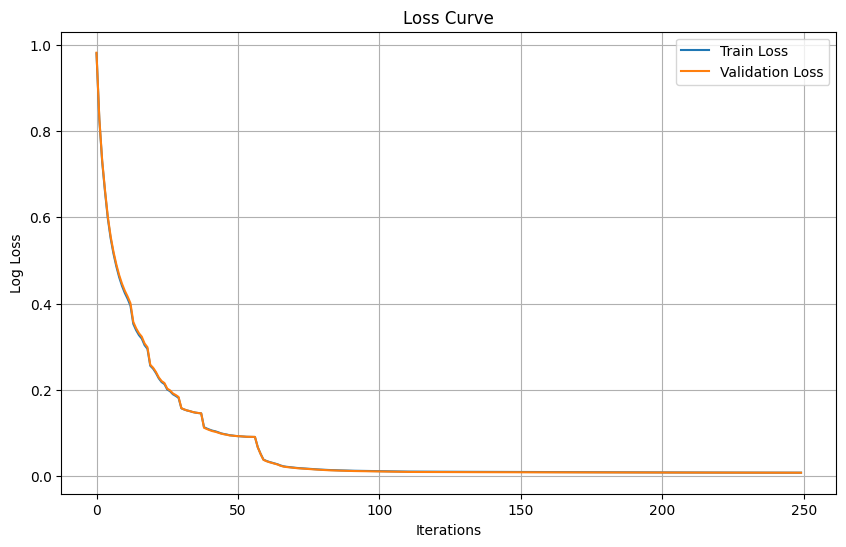

In [252]:
def make_loss_plot():
    results = xgb_model.evals_result()
    plt.figure(figsize=(10, 6))
    plt.plot(results['validation_0']['logloss'], label='Train Loss')
    plt.plot(results['validation_1']['logloss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Log Loss')
    plt.legend()
    plt.grid()
    plt.show()

y_pred_probs = xgb_model.predict_proba(X_test)[:, 1]

def make_roc_plot():
    from sklearn.metrics import roc_curve, auc

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
    plt.title('XGBoost: ROC Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend()
    plt.grid()
    # plt.show()
    plt.savefig(f'{results_dir}ROC_curve_XGB_{day}.png')
    plt.close()

def make_precission_recall_plot():
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
    average_precision = average_precision_score(y_test, y_pred_probs)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
    plt.title('XGBoost: Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    # plt.show()
    plt.savefig(f'{results_dir}Precision_Recall_curve_XGB_{day}.png')
    plt.close()

# Save classification report to file
report = classification_report(y_test, y_pred, target_names=['BENIGN', 'MALICIOUS'])
with open(f'{results_dir}Classification_Report_XGB_{day}.txt', 'w') as f:
    f.write(report)
print(report)

# Make and save plots
make_loss_plot()
make_roc_plot()
make_precission_recall_plot()

# Optional: Save confusion matrix as an image
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='coolwarm', 
                xticklabels=['BENIGN (Predicted)', 'MALICIOUS (Predicted)'], 
                yticklabels=['BENIGN (Actual)', 'MALICIOUS (Actual)'])

labels = [[f'TN: {cm[0][0]}', f'FP: {cm[0][1]}'], 
          [f'FN: {cm[1][0]}', f'TP: {cm[1][1]}']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, f'\n({labels[i][j]})', 
                color='Black', ha='center', va='center', fontsize=10)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost: Confusion Matrix Heatmap')
plt.savefig(f'{results_dir}Confusion_Matrix_XGB_{day}.png')
plt.close()